In [2]:
import numpy as np

import pennylane as qml

In [3]:
device = qml.device("default.qubit", wires=5)

In [4]:
from pennylane.measurements import ExpectationMP

# set qubit state from angle matrix
def init_qubit(matrix: np.ndarray, qubit: int):
    qml.RX(phi=matrix[0], wires=qubit)
    qml.RY(phi=matrix[1], wires=qubit)
    qml.RZ(phi=matrix[2], wires=qubit)

# get qubit state as matrix
def get_qubit_state(qubit: int) -> tuple[ExpectationMP, ExpectationMP, ExpectationMP]:
    return qml.expval(qml.PauliX(wires=qubit)), qml.expval(qml.PauliY(wires=qubit)), qml.expval(qml.PauliZ(wires=qubit))

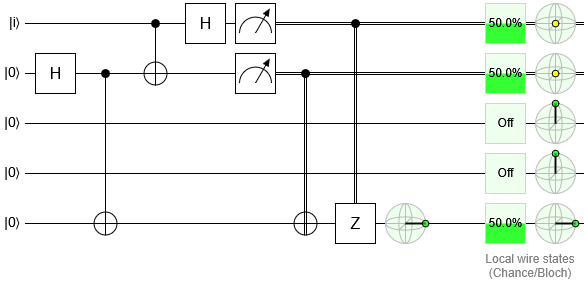

In [5]:
INITIAL_QBIT = 0
ALICE_QBIT = 1
BOB_QBIT = 4

In [6]:
@qml.qnode(device)
def quantum_teleport(matrix: np.ndarray):
    init_qubit(matrix, INITIAL_QBIT)

    qml.Hadamard(wires=ALICE_QBIT)
    qml.CNOT(wires=[ALICE_QBIT, BOB_QBIT])
    qml.CNOT(wires=[INITIAL_QBIT, ALICE_QBIT])
    qml.Hadamard(wires=INITIAL_QBIT)

    # measure 1 and 2 qubits
    m0 = qml.measure(INITIAL_QBIT)
    m1 = qml.measure(ALICE_QBIT)
    
    qml.cond(m1, qml.PauliX)(wires=BOB_QBIT) # type: ignore
    qml.cond(m0, qml.PauliZ)(wires=BOB_QBIT) # type: ignore

    return get_qubit_state(BOB_QBIT)


In [7]:
def Hadamard(wires):
    qml.RZ(np.pi, wires=wires)
    qml.RY(np.pi/2, wires=wires)
    qml.RZ(np.pi, wires=wires)

def MS(wires: list):
    qml.RY(np.pi/2, wires=wires[0])
    qml.RY(np.pi/2, wires=wires[1])
    qml.IsingZZ(np.pi/2, wires=wires)
    qml.RY(-np.pi/2, wires=wires[0])
    qml.RY(-np.pi/2, wires=wires[1])

# Google SD-style
def CNOT(wires: list):
    _, target = wires
    Hadamard(target)
    qml.CZ(wires=wires)
    qml.Hadamard(target)

def CNOT_ionq(wires: list):
    control, target = wires
    qml.RY(np.pi/2, wires=control)
    MS(wires)
    qml.RX(-np.pi/2, wires=control)
    qml.RX(-np.pi/2, wires=target)
    qml.RY(-np.pi/2, wires=control)

def SWAP(wires: list):
    CNOT(wires)
    CNOT(wires[::-1])
    CNOT(wires)


In [8]:
# ионный
@qml.qnode(device)
def ionq_qt(matrix: np.ndarray):
    init_qubit(matrix, INITIAL_QBIT)
    
    Hadamard(ALICE_QBIT)
    CNOT_ionq([ALICE_QBIT, BOB_QBIT])
    
    CNOT_ionq([INITIAL_QBIT, ALICE_QBIT])
    Hadamard(INITIAL_QBIT)
    
    m0 = qml.measure(INITIAL_QBIT)
    m1 = qml.measure(ALICE_QBIT)
    
    qml.cond(m1, qml.PauliX)(wires=BOB_QBIT)
    qml.cond(m0, qml.PauliZ)(wires=BOB_QBIT)
    
    return get_qubit_state(BOB_QBIT)

In [9]:
# не можем использовать BOB_QBIT, так как он физически отделен

# сверхпроводниковый
@qml.qnode(device)
def sd_qt(matrix: np.ndarray):
    init_qubit(matrix, INITIAL_QBIT)

    new_bob_qbit = BOB_QBIT

    # SWAP BOB_QBIT to ALICE_QBIT+1 position
    if new_bob_qbit - ALICE_QBIT != 1:
        while(new_bob_qbit != ALICE_QBIT + 1):
            SWAP([new_bob_qbit, new_bob_qbit-1])
            new_bob_qbit = new_bob_qbit - 1
            


    Hadamard(ALICE_QBIT)
    CNOT([ALICE_QBIT, new_bob_qbit])
    
    CNOT([INITIAL_QBIT, ALICE_QBIT])
    Hadamard(INITIAL_QBIT)

    m0 = qml.measure(INITIAL_QBIT)
    m1 = qml.measure(ALICE_QBIT)
    
    qml.cond(m1, qml.PauliX)(wires=new_bob_qbit)
    qml.cond(m0, qml.PauliZ)(wires=new_bob_qbit)
    
    return get_qubit_state(new_bob_qbit)


In [10]:
# задаем матрицу углов поворота (X, Y, Z)
matrix = np.array([
    np.pi, np.pi/4, 0
])


print(ionq_qt(matrix))
print(quantum_teleport(matrix))
print(sd_qt(matrix))


print("Количество гейтов в абстрактной схеме", len(quantum_teleport._tape.operations))
print("Количество гейтов в ionq:", len(ionq_qt._tape.operations))
print("Количество гейтов в SD:", len(sd_qt._tape.operations))


(np.float64(0.7071067811865496), np.float64(0.0), np.float64(-0.7071067811865493))
(np.float64(-0.7071067811865471), np.float64(0.0), np.float64(-0.7071067811865471))
(np.float64(0.7071067811865475), np.float64(0.0), np.float64(-0.7071067811865477))
Количество гейтов в абстрактной схеме 11
Количество гейтов в ionq: 31
Количество гейтов в SD: 53


<BarContainer object of 3 artists>

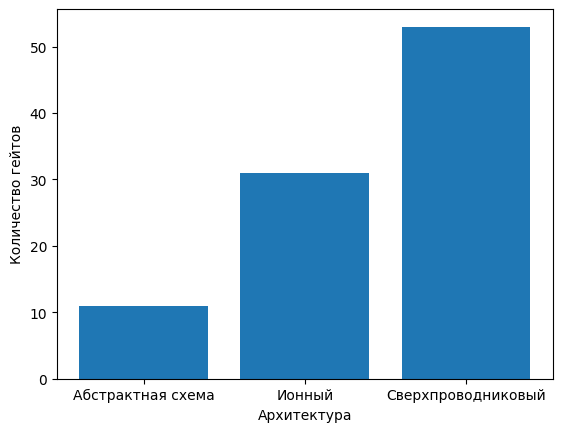

In [12]:
import matplotlib.pyplot as plt

plt.xlabel("Архитектура")
plt.ylabel("Количество гейтов")
plt.bar(["Абстрактная схема", "Ионный", "Сверхпроводниковый"], [len(quantum_teleport._tape.operations), len(ionq_qt._tape.operations), len(sd_qt._tape.operations)])